In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/INDENG 290') # customize this line to your working directory

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install contextily
!pip install keplergl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 60.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MB 63.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ipywidgets-8.1.6-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyter_packaging-0.12.3-py3-none-any.whl.metadata (7.7 kB)
  Using cached comm-0.2.2-py3-none-any.whl.metadata (3.7 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached deprecation-2.1.0-py2.py3-none-any.whl.metadata (4.6 kB)
  Using cached tomlkit-0.13.2-py3-none-any.whl.metadata (2.7 kB)
  Using cached async_lru-2.0.5-py3-none-any.whl.metadata (4.5 kB)
  Using cached jupyter_lsp-2.2.5-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.15.0-py3-none-any.whl.metadata (8.4 kB)
  Using cached jupyterlab_server-2.27.3-py3-none-any.whl.metadata (5.9 kB)
  Using 

In [ ]:
!pip install simpy

In [ ]:
# Data manipulation and numerical operations
import pandas as pd           # For dataframes and data cleaning
import numpy as np            # For numerical calculations

# Geospatial analysis
import geopandas as gpd       # For handling geospatial data (shapefiles, projections, etc.)
from shapely.geometry import Point, Polygon  # For creating geometric objects like points and polygons
import pyproj                 # For coordinate system transformations
import contextily as ctx      # For adding basemap tiles (e.g., OpenStreetMap)

# Visualization
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Statistical and density plotting (e.g., KDE)
import folium                     # Interactive leaflet-style maps
from folium.plugins import HeatMap  # For adding heatmaps on folium maps

# Advanced interactive mapping (optional)
from keplergl import KeplerGl    # For powerful interactive map visualizations in browser

# Mathematical modeling and optimization
from scipy.spatial import distance_matrix        # For computing pairwise distances between coordinates
from scipy.optimize import linear_sum_assignment # For solving assignment/optimization problems
from sklearn.cluster import KMeans               # For clustering accident hotspots or resource placement

# Graph-based modeling
import networkx as nx           # For graph-based routing and shortest path modeling

# Discrete event simulation (optional, for queueing models)
import simpy                    # For simulating queueing systems like ambulance dispatch

# Utilities
import datetime                 # For handling datetime formats
import warnings                 # To suppress warning messages during runtime
warnings.filterwarnings("ignore")

data source:

In [ ]:
df = pd.read_csv('Traffic_Crashes_Resulting_in_Injury_20250421.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61702 entries, 0 to 61701
Data columns (total 63 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   unique_id                     61702 non-null  int64  
 1   cnn_intrsctn_fkey             61674 non-null  float64
 2   cnn_sgmt_fkey                 27557 non-null  float64
 3   case_id_pkey                  61702 non-null  object 
 4   tb_latitude                   61529 non-null  float64
 5   tb_longitude                  61529 non-null  float64
 6   geocode_source                61702 non-null  object 
 7   geocode_location              61702 non-null  object 
 8   collision_datetime            61702 non-null  object 
 9   collision_date                61702 non-null  object 
 10  collision_time                61642 non-null  object 
 11  accident_year                 61702 non-null  int64  
 12  month                         61702 non-null  object 
 13  d

In [ ]:
df

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,data_updated_at,data_loaded_at,analysis_neighborhood,supervisor_district,police_district,Current Police Districts,Current Supervisor Districts,Analysis Neighborhoods,Neighborhoods,SF Find Neighborhoods
0,40386,27145000.0,7847000.0,150419581,37.760300,-122.466325,SFPD-CROSSROADS,CITY STREET,05/14/2015 01:15:00 PM,2015 May 14,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,Inner Sunset,7.0,TARAVAL,10.0,8.0,14.0,109.0,109.0
1,91730,24911000.0,3432000.0,240648080,37.790404,-122.406851,SFPD-INTERIM DB,CITY STREET,10/15/2024 12:29:00 AM,2024 October 15,...,04/08/2025 12:00:00 AM,04/08/2025 04:30:19 PM,Financial District/South Beach,3.0,CENTRAL,6.0,3.0,8.0,104.0,104.0
2,5788,33284000.0,2800202.0,150638797,37.742285,-122.405916,SFPD-CROSSROADS,CITY STREET,07/22/2015 09:30:00 PM,2015 July 22,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,Bernal Heights,9.0,BAYVIEW,2.0,2.0,2.0,82.0,82.0
3,10457,25631000.0,NaN,3843463,37.755029,-122.425457,SFPD-CROSSROADS,CITY STREET,07/27/2008 09:00:00 PM,2008 July 27,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,Noe Valley,8.0,MISSION,3.0,5.0,22.0,52.0,52.0
4,92561,21898000.0,NaN,230757362,37.748773,-122.422571,SFPD-INTERIM DB,CITY STREET,10/22/2023 03:51:00 PM,2023 October 22,...,04/08/2025 12:00:00 AM,04/08/2025 04:30:19 PM,Mission,8.0,MISSION,3.0,5.0,20.0,52.0,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61697,14294,24350000.0,NaN,130084756,37.772649,-122.415002,SFPD-CROSSROADS,CITY STREET,01/29/2013 08:20:00 AM,2013 January 29,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,South of Market,6.0,SOUTHERN,1.0,10.0,34.0,32.0,32.0
61698,43318,27230000.0,6056201.0,150044774,37.781258,-122.458857,SFPD-CROSSROADS,CITY STREET,01/15/2015 01:39:00 PM,2015 January 15,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,Lone Mountain/USF,2.0,RICHMOND,8.0,4.0,18.0,11.0,11.0
61699,23907,24590000.0,NaN,140757357,37.785030,-122.400468,SFPD-CROSSROADS,CITY STREET,09/08/2014 06:00:00 PM,2014 September 08,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,Financial District/South Beach,6.0,SOUTHERN,1.0,10.0,8.0,32.0,32.0
61700,3235,33269000.0,NaN,150766235,37.734014,-122.390968,SFPD-CROSSROADS,CITY STREET,09/01/2015 09:35:00 AM,2015 September 01,...,04/26/2023 12:00:00 AM,04/08/2025 04:30:19 PM,Bayview Hunters Point,10.0,BAYVIEW,2.0,9.0,1.0,87.0,87.0


# **SFCrash Dataset Preprocessing**

In [ ]:
data_types = df.dtypes.value_counts()

print("Data Types Summary:")
for dtype, count in data_types.items():
    print(f"- {dtype}: {count} columns")

Data Types Summary:
- object: 47 columns
- float64: 13 columns
- int64: 3 columns


In [ ]:
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

class CrashDataProcessor:
    """SF Traffic Crash Data Cleaning and Feature Engineering Class"""

    def __init__(self, data):
        self.data = data.copy()
        self.clean_data = None

    def clean_data_pipeline(self):
        """Main data cleaning pipeline"""
        print("Starting data cleaning...")

        # 1. Handle duplicates
        self.handle_duplicates()

        # 2. Handle missing values
        self.handle_missing_values()

        # 3. Convert data types
        self.convert_data_types()

        # 4. Handle outliers
        self.handle_outliers()

        # 5. Check data consistency
        self.check_data_consistency()

        self.clean_data = self.data.copy()
        print("Data cleaning completed!")
        return self.clean_data

    def handle_duplicates(self):
        """Handle duplicate records"""
        print("Checking for duplicates...")
        duplicates = self.data.duplicated(subset=['case_id_pkey']).sum()
        if duplicates > 0:
            print(f"Found {duplicates} duplicate records, removing...")
            self.data = self.data.drop_duplicates(subset=['case_id_pkey'])
        else:
            print("No duplicate records found")

    def handle_missing_values(self):
        """Handle missing values"""
        print("Handling missing values...")

        # Geographic coordinates handling
        coords_missing = self.data['tb_latitude'].isna() | self.data['tb_longitude'].isna()
        print(f"Records with missing coordinates: {coords_missing.sum()}")

        # Mark records with missing coordinates
        self.data.loc[coords_missing, 'missing_coords'] = True

        # Time missing value handling
        time_missing = self.data['collision_time'].isna()
        print(f"Records with missing collision time: {time_missing.sum()}")
        self.data['collision_time'].fillna('00:00:00', inplace=True)
        self.data['has_time_missing'] = time_missing

        # Weather condition missing value handling
        if 'weather_1' in self.data.columns:
            self.data['weather_1'].fillna('Not Stated', inplace=True)

        # Road condition missing value handling
        if 'road_cond_1' in self.data.columns:
            self.data['road_cond_1'].fillna('Not Stated', inplace=True)
        if 'road_surface' in self.data.columns:
            self.data['road_surface'].fillna('Not Stated', inplace=True)

        # Numeric missing value imputation
        self.data['number_killed'].fillna(0, inplace=True)
        self.data['number_injured'].fillna(0, inplace=True)
        self.data['distance'].fillna(self.data['distance'].median(), inplace=True)

        # Categorical variable missing value handling
        categorical_cols = ['party_at_fault', 'party1_type', 'party2_type',
                          'party1_dir_of_travel', 'party2_dir_of_travel',
                          'party1_move_pre_acc', 'party2_move_pre_acc']

        for col in categorical_cols:
            if col in self.data.columns:
                self.data[col].fillna('UNKNOWN', inplace=True)

    def convert_data_types(self):
        """Convert data types"""
        print("Converting data types...")

        # Date-time conversion
        self.data['collision_datetime'] = pd.to_datetime(self.data['collision_datetime'],
                                                        format='%m/%d/%Y %I:%M:%S %p',
                                                        errors='coerce')
        self.data['collision_date'] = pd.to_datetime(self.data['collision_date'],
                                                    format='%Y %B %d',
                                                    errors='coerce')

        # Numeric type conversion
        numeric_cols = ['cnn_intrsctn_fkey', 'cnn_sgmt_fkey', 'number_killed',
                       'number_injured', 'supervisor_district', 'Current Police Districts']

        for col in numeric_cols:
            if col in self.data.columns:
                self.data[col] = pd.to_numeric(self.data[col], errors='coerce')

    def handle_outliers(self):
        """Handle outliers"""
        print("Handling outliers...")

        # Coordinate outlier handling
        sf_lat_bounds = (37.7, 37.85)  # San Francisco latitude bounds
        sf_lon_bounds = (-122.52, -122.36)  # San Francisco longitude bounds

        coord_outliers = ((self.data['tb_latitude'] < sf_lat_bounds[0]) |
                         (self.data['tb_latitude'] > sf_lat_bounds[1]) |
                         (self.data['tb_longitude'] < sf_lon_bounds[0]) |
                         (self.data['tb_longitude'] > sf_lon_bounds[1]))

        print(f"Records with coordinate outliers: {coord_outliers.sum()}")
        self.data.loc[coord_outliers, 'coord_outlier'] = True

        # Casualty outlier checking
        casualty_outliers = (self.data['number_killed'] > 10) | (self.data['number_injured'] > 20)
        print(f"Records with casualty outliers: {casualty_outliers.sum()}")
        self.data.loc[casualty_outliers, 'casualty_outlier'] = True

    def check_data_consistency(self):
        """Check data consistency"""
        print("Checking data consistency...")

        # Check date-time consistency
        date_time_inconsistent = (self.data['collision_datetime'].dt.date !=
                                self.data['collision_date'].dt.date)
        print(f"Records with date-time inconsistency: {date_time_inconsistent.sum()}")
        self.data.loc[date_time_inconsistent, 'date_time_inconsistent'] = True

    def feature_engineering(self):
        """Feature engineering main process"""
        if self.clean_data is None:
            self.clean_data_pipeline()

        print("Starting feature engineering...")

        # Extract time features
        self.extract_time_features()

        # Extract spatial features
        self.extract_spatial_features()

        # Extract accident features
        self.extract_accident_features()

        # Extract environmental features
        self.extract_environmental_features()

        print("Feature engineering completed!")
        return self.data

    def extract_time_features(self):
        """Extract time-related features"""
        print("Extracting time features...")

        # Basic time features
        self.data['year'] = self.data['collision_datetime'].dt.year
        self.data['month'] = self.data['collision_datetime'].dt.month
        self.data['day'] = self.data['collision_datetime'].dt.day
        self.data['hour'] = self.data['collision_datetime'].dt.hour

        # Create numeric day of week (0 = Monday, 6 = Sunday)
        self.data['day_of_week_num'] = self.data['collision_datetime'].dt.dayofweek

        # Create day name (Monday, Tuesday, etc.)
        self.data['day_of_week'] = self.data['collision_datetime'].dt.day_name()

        # Weekend flag
        self.data['is_weekend'] = self.data['day_of_week_num'].isin([5, 6]).astype(int)

        # Time period classification
        def get_time_period(hour):
            if 5 <= hour < 12:
                return 'Morning'
            elif 12 <= hour < 17:
                return 'Afternoon'
            elif 17 <= hour < 21:
                return 'Evening'
            else:
                return 'Night'

        self.data['time_of_day'] = self.data['hour'].apply(get_time_period)

        # Hour category feature - formatted as "HH:00"
        self.data['hour_category'] = self.data['hour'].apply(lambda x: f"{x:02d}:00")

        # Rush hour identification
        self.data['is_rush_hour'] = ((self.data['hour'].isin([7, 8, 9, 16, 17, 18])) &
                                    (~self.data['is_weekend'].astype(bool))).astype(int)

        # Season feature
        def get_season(month):
            if month in [12, 1, 2]:
                return 'Winter'
            elif month in [3, 4, 5]:
                return 'Spring'
            elif month in [6, 7, 8]:
                return 'Summer'
            else:
                return 'Fall'

        self.data['season'] = self.data['month'].apply(get_season)

    def extract_spatial_features(self):
        """Extract spatial features"""
        print("Extracting spatial features...")

        # Zone features
        self.data['has_intersection'] = (~self.data['cnn_intrsctn_fkey'].isna()).astype(int)
        self.data['has_segment'] = (~self.data['cnn_sgmt_fkey'].isna()).astype(int)

        # Neighborhood grouping
        neighborhood_mapping = {
            'Financial District/South Beach': 'Downtown',
            'Chinatown': 'Downtown',
            'Nob Hill': 'Downtown',
            'North Beach': 'Downtown',
            'Russian Hill': 'Downtown',
            'SOMA': 'Downtown',
            # ... add more mappings as needed
        }

        self.data['neighborhood_group'] = self.data['analysis_neighborhood'].map(
            lambda x: neighborhood_mapping.get(x, x)
        )

        # Calculate distance to city center
        sf_center = (37.7749, -122.4194)  # San Francisco city center coordinates
        self.data['distance_to_center'] = np.sqrt(
            (self.data['tb_latitude'] - sf_center[0])**2 +
            (self.data['tb_longitude'] - sf_center[1])**2
        )

    def extract_accident_features(self):
        """Extract accident-related features"""
        print("Extracting accident features...")

        # Severity metrics
        self.data['total_casualties'] = self.data['number_killed'] + self.data['number_injured']
        self.data['is_fatal'] = (self.data['number_killed'] > 0).astype(int)
        self.data['is_injury'] = (self.data['number_injured'] > 0).astype(int)

        # Collision type simplification
        collision_type_mapping = {
            'VEHICLE - PEDESTRIAN': 'Pedestrian',
            'VEHICLE - VEHICLE': 'Vehicle',
            'VEHICLE - BICYCLE': 'Bicycle',
            'VEHICLE - FIXED OBJECT': 'Fixed Object',
            'VEHICLE - NON COLLISION': 'Non Collision'
        }

        self.data['collision_type_simple'] = self.data['type_of_collision'].map(
            lambda x: collision_type_mapping.get(x, 'Other')
        )

        # Number of parties involved
        self.data['num_parties'] = 1 + (~self.data['party2_type'].isna()).astype(int)

        # Pedestrian involvement
        self.data['involves_pedestrian'] = (
            (self.data['party1_type'] == 'PEDESTRIAN') |
            (self.data['party2_type'] == 'PEDESTRIAN')
        ).astype(int)

        # Bicycle involvement
        self.data['involves_bicycle'] = (
            (self.data['party1_type'] == 'BICYCLE') |
            (self.data['party2_type'] == 'BICYCLE')
        ).astype(int)

    def extract_environmental_features(self):
        """Extract environmental features"""
        print("Extracting environmental features...")

        # Weather condition simplification - 只使用 weather_1
        weather_mapping = {
            'Clear': 'Good',
            'CLEAR': 'Good',
            'Cloudy': 'Good',
            'Raining': 'Bad',
            'Wind': 'Moderate',
            'Fog': 'Bad',
            'Fog / Visibility': 'Bad',
            'Fog / Visibility: 10 ft': 'Bad',
            'Fog / Visibility: 15 ft': 'Bad',
            'Fog / Visibility: 30 ft': 'Bad',
            'Fog / Visibility: 100 ft': 'Bad',
            'Fog / Visibility: 500 ft': 'Bad',
            'Fog / Visibility: 800 ft': 'Bad',
            'Snowing': 'Bad',
            'Not Stated': 'Unknown',
            'Other': 'Unknown',
            'Other: Unknown': 'Unknown',
            'Other: NOT ON SCENE': 'Unknown',
            'Other: NOT AT SCENE': 'Unknown',
            'Other: MIST': 'Moderate',
            'Other: MISTING': 'Moderate',
            'Other: Drizzling': 'Moderate',
            'Other: light drizzle': 'Moderate',
            'Other: Light drizzle (rain)': 'Moderate',
            'Other: LIGHT SPRINKLE': 'Moderate',
            'Other: smoke cloud': 'Bad',
            'Other: Wet roads': 'Moderate',
            'Other: SUNNY': 'Good',
            'Other: Sunny': 'Good',
            'Other: drizzle': 'Moderate',
            'Other: SUNRISE': 'Good',
            'Other: LIGHT MIST': 'Moderate',
            'Other: SMOKEY SKIES': 'Bad',
            'Other: MISTY': 'Moderate',
            'Other: WET PAVEMENT': 'Moderate',
            'Other: SUNSET': 'Good',
            'Other: SLIGHT MIST': 'Moderate',
            'Other: SUN IN WB VIEW': 'Moderate',
            'Other: Sunset': 'Good',
            'Other: SUN GLARING': 'Moderate',
            'Other: Night': 'Unknown',
            'Other: Misty': 'Moderate',
            'Other: Overcast': 'Moderate',
            'Other: Mist': 'Moderate',
            'Other: FALLING ASH': 'Bad',
            'Other: HEAVY MIST': 'Bad'
        }

        # 只使用 weather_1
        self.data['weather_condition'] = self.data['weather_1'].map(
            lambda x: weather_mapping.get(x, 'Unknown')
        )

        # Lighting condition simplification
        lighting_mapping = {
            'Daylight': 'Good',
            'Dark - Street Lights': 'Moderate',
            'Not Stated': 'Unknown',
            'Dusk - Dawn': 'Poor',
            'Dark - No Street Lights': 'Poor',
            'Dark - Street Lights Not Functioning': 'Poor'
        }

        self.data['lighting_condition'] = self.data['lighting'].map(
            lambda x: lighting_mapping.get(x, 'Unknown')
        )

        # Road surface condition simplification
        road_surface_mapping = {
            'Dry': 'Good',
            'Wet': 'Poor',
            'Not Stated': 'Unknown',
            'Slippery': 'Poor',
            'Snowy or Icy': 'Poor'
        }

        self.data['road_surface_condition'] = self.data['road_surface'].map(
            lambda x: road_surface_mapping.get(x, 'Unknown')
        )

        # Road condition simplification - 只使用 road_cond_1
        road_condition_mapping = {
            'No Unusual Condition': 'Good',
            'Other': 'Unknown',
            'Not Stated': 'Unknown',
            'Loose Material on Roadway': 'Poor',
            'Holes, Deep Ruts': 'Poor',
            'Holes, Deep Rut': 'Poor',
            'Obstruction on Roadway': 'Poor',
            'Flooded': 'Poor',
            'Construction or Repair Zone': 'Poor',
            'Reduced Roadway Width': 'Poor'
        }

        # 只使用 road_cond_1
        self.data['road_condition'] = self.data['road_cond_1'].map(
            lambda x: road_condition_mapping.get(x, 'Unknown')
        )

        # Environmental risk index
        risk_scores = {
            'weather_condition': {'Good': 0, 'Moderate': 1, 'Bad': 2, 'Unknown': 1},
            'lighting_condition': {'Good': 0, 'Moderate': 1, 'Poor': 2, 'Unknown': 1},
            'road_condition': {'Good': 0, 'Poor': 2, 'Unknown': 1},
            'road_surface_condition': {'Good': 0, 'Poor': 2, 'Unknown': 1}
        }

        self.data['environmental_risk_score'] = (
            self.data['weather_condition'].map(risk_scores['weather_condition']) +
            self.data['lighting_condition'].map(risk_scores['lighting_condition']) +
            self.data['road_condition'].map(risk_scores['road_condition']) +
            self.data['road_surface_condition'].map(risk_scores['road_surface_condition'])
        )

# Usage example
def process_crash_data(df):
    """Main function to process crash data"""
    processor = CrashDataProcessor(df)

    # Execute data cleaning
    clean_data = processor.clean_data_pipeline()

    # Execute feature engineering
    processed_data = processor.feature_engineering()

    # Generate data quality report
    generate_data_quality_report(processed_data)

    return processed_data

def generate_data_quality_report(df):
    """Generate data quality report"""
    print("\n=== Data Quality Report ===")
    print(f"Total records: {len(df)}")
    print(f"Total features: {len(df.columns)}")

    # Missing value statistics
    missing_stats = df.isnull().sum().sort_values(ascending=False)
    print("\nMissing value statistics (top 10):")
    print(missing_stats[missing_stats > 0][:10])

    # Data type distribution
    print("\nData type distribution:")
    print(df.dtypes.value_counts())

    # Key metrics statistics
    print("\nKey metrics statistics:")
    print(f"Fatal accidents: {df['is_fatal'].sum()}")
    print(f"Injury accidents: {df['is_injury'].sum()}")
    print(f"Total casualties: {df['total_casualties'].sum()}")
    print(f"Pedestrian involved accidents: {df['involves_pedestrian'].sum()}")
    print(f"Bicycle involved accidents: {df['involves_bicycle'].sum()}")

    # Spatial-temporal distribution
    print("\nSpatial-temporal distribution:")
    print(f"Year range: {df['year'].min()} - {df['year'].max()}")
    print(f"Number of neighborhoods: {df['analysis_neighborhood'].nunique()}")
    print(f"Number of police districts: {df['police_district'].nunique()}")

    # Outlier statistics
    print("\nOutlier statistics:")
    print(f"Coordinate outliers: {df['coord_outlier'].sum() if 'coord_outlier' in df else 0}")
    print(f"Casualty outliers: {df['casualty_outlier'].sum() if 'casualty_outlier' in df else 0}")
    print(f"Date-time inconsistencies: {df['date_time_inconsistent'].sum() if 'date_time_inconsistent' in df else 0}")

    # Preliminary feature importance assessment
    if 'is_fatal' in df:
        print("\nPreliminary feature correlation analysis (with fatal accidents):")
        correlations = df[['is_fatal', 'hour', 'is_weekend', 'is_rush_hour',
                          'involves_pedestrian', 'involves_bicycle',
                          'environmental_risk_score']].corr()['is_fatal'].sort_values(ascending=False)
        print(correlations)

In [ ]:
# Execute data processing
processed_data = process_crash_data(df)
processed_data.to_csv('processed_crash_data.csv', index=False)

Starting data cleaning...
Checking for duplicates...
No duplicate records found
Handling missing values...
Records with missing coordinates: 173
Records with missing collision time: 0
Converting data types...
Handling outliers...
Records with coordinate outliers: 4
Records with casualty outliers: 0
Checking data consistency...
Records with date-time inconsistency: 0
Data cleaning completed!
Starting feature engineering...
Extracting time features...
Extracting spatial features...
Extracting accident features...
Extracting environmental features...
Feature engineering completed!

=== Data Quality Report ===
Total records: 61700
Total features: 99

Missing value statistics (top 10):
casualty_outlier          61700
date_time_inconsistent    61700
coord_outlier             61696
missing_coords            61527
cnn_sgmt_fkey             34145
reporting_district         6510
beat_number                4701
SF Find Neighborhoods      1283
Neighborhoods              1283
officer_id            

In [ ]:
df = processed_data
df

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,lighting_condition,road_condition_simple,environmental_risk_score,weather_1_simple,weather_2_simple,road_surface_condition,road_cond_1_simple,road_cond_2_simple,road_condition_combined,road_condition
0,40386,27145000.0,7847000.0,150419581,37.760300,-122.466325,SFPD-CROSSROADS,CITY STREET,2015-05-14 13:15:00,2015-05-14,...,Good,Unknown,1,Good,Unknown,Good,Unknown,Unknown,Unknown,Unknown
1,91730,24911000.0,3432000.0,240648080,37.790404,-122.406851,SFPD-INTERIM DB,CITY STREET,2024-10-15 00:29:00,2024-10-15,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
2,5788,33284000.0,2800202.0,150638797,37.742285,-122.405916,SFPD-CROSSROADS,CITY STREET,2015-07-22 21:30:00,2015-07-22,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
3,10457,25631000.0,NaN,3843463,37.755029,-122.425457,SFPD-CROSSROADS,CITY STREET,2008-07-27 21:00:00,2008-07-27,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
4,92561,21898000.0,NaN,230757362,37.748773,-122.422571,SFPD-INTERIM DB,CITY STREET,2023-10-22 15:51:00,2023-10-22,...,Good,Unknown,5,Bad,Unknown,Poor,Unknown,Unknown,Poor,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61697,14294,24350000.0,NaN,130084756,37.772649,-122.415002,SFPD-CROSSROADS,CITY STREET,2013-01-29 08:20:00,2013-01-29,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61698,43318,27230000.0,6056201.0,150044774,37.781258,-122.458857,SFPD-CROSSROADS,CITY STREET,2015-01-15 13:39:00,2015-01-15,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61699,23907,24590000.0,NaN,140757357,37.785030,-122.400468,SFPD-CROSSROADS,CITY STREET,2014-09-08 18:00:00,2014-09-08,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61700,3235,33269000.0,NaN,150766235,37.734014,-122.390968,SFPD-CROSSROADS,CITY STREET,2015-09-01 09:35:00,2015-09-01,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good


In [ ]:
df['weather_condition'].value_counts()

,count
weather_condition,
Good,56814
Bad,3925
Unknown,911
Moderate,50


In [ ]:
df['road_surface_condition'].value_counts()

,count
road_surface_condition,
Good,54199
Poor,6415
Unknown,1086


In [ ]:
df['lighting_condition'].value_counts()

,count
lighting_condition,
Good,39727
Moderate,18641
Poor,2724
Unknown,608


In [ ]:
df['road_condition'].value_counts()

,count
road_condition,
Good,58313
Unknown,2190
Poor,1197


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61700 entries, 0 to 61701
Data columns (total 98 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   unique_id                     61700 non-null  int64         
 1   cnn_intrsctn_fkey             61672 non-null  float64       
 2   cnn_sgmt_fkey                 27555 non-null  float64       
 3   case_id_pkey                  61700 non-null  object        
 4   tb_latitude                   61527 non-null  float64       
 5   tb_longitude                  61527 non-null  float64       
 6   geocode_source                61700 non-null  object        
 7   geocode_location              61700 non-null  object        
 8   collision_datetime            61700 non-null  datetime64[ns]
 9   collision_date                61700 non-null  datetime64[ns]
 10  collision_time                61700 non-null  object        
 11  accident_year                 617

# **SFCrash Dataset EDA**

## Temporal EDA Analysis

Summary visualization saved to: results/temporal_analysis_summary.png


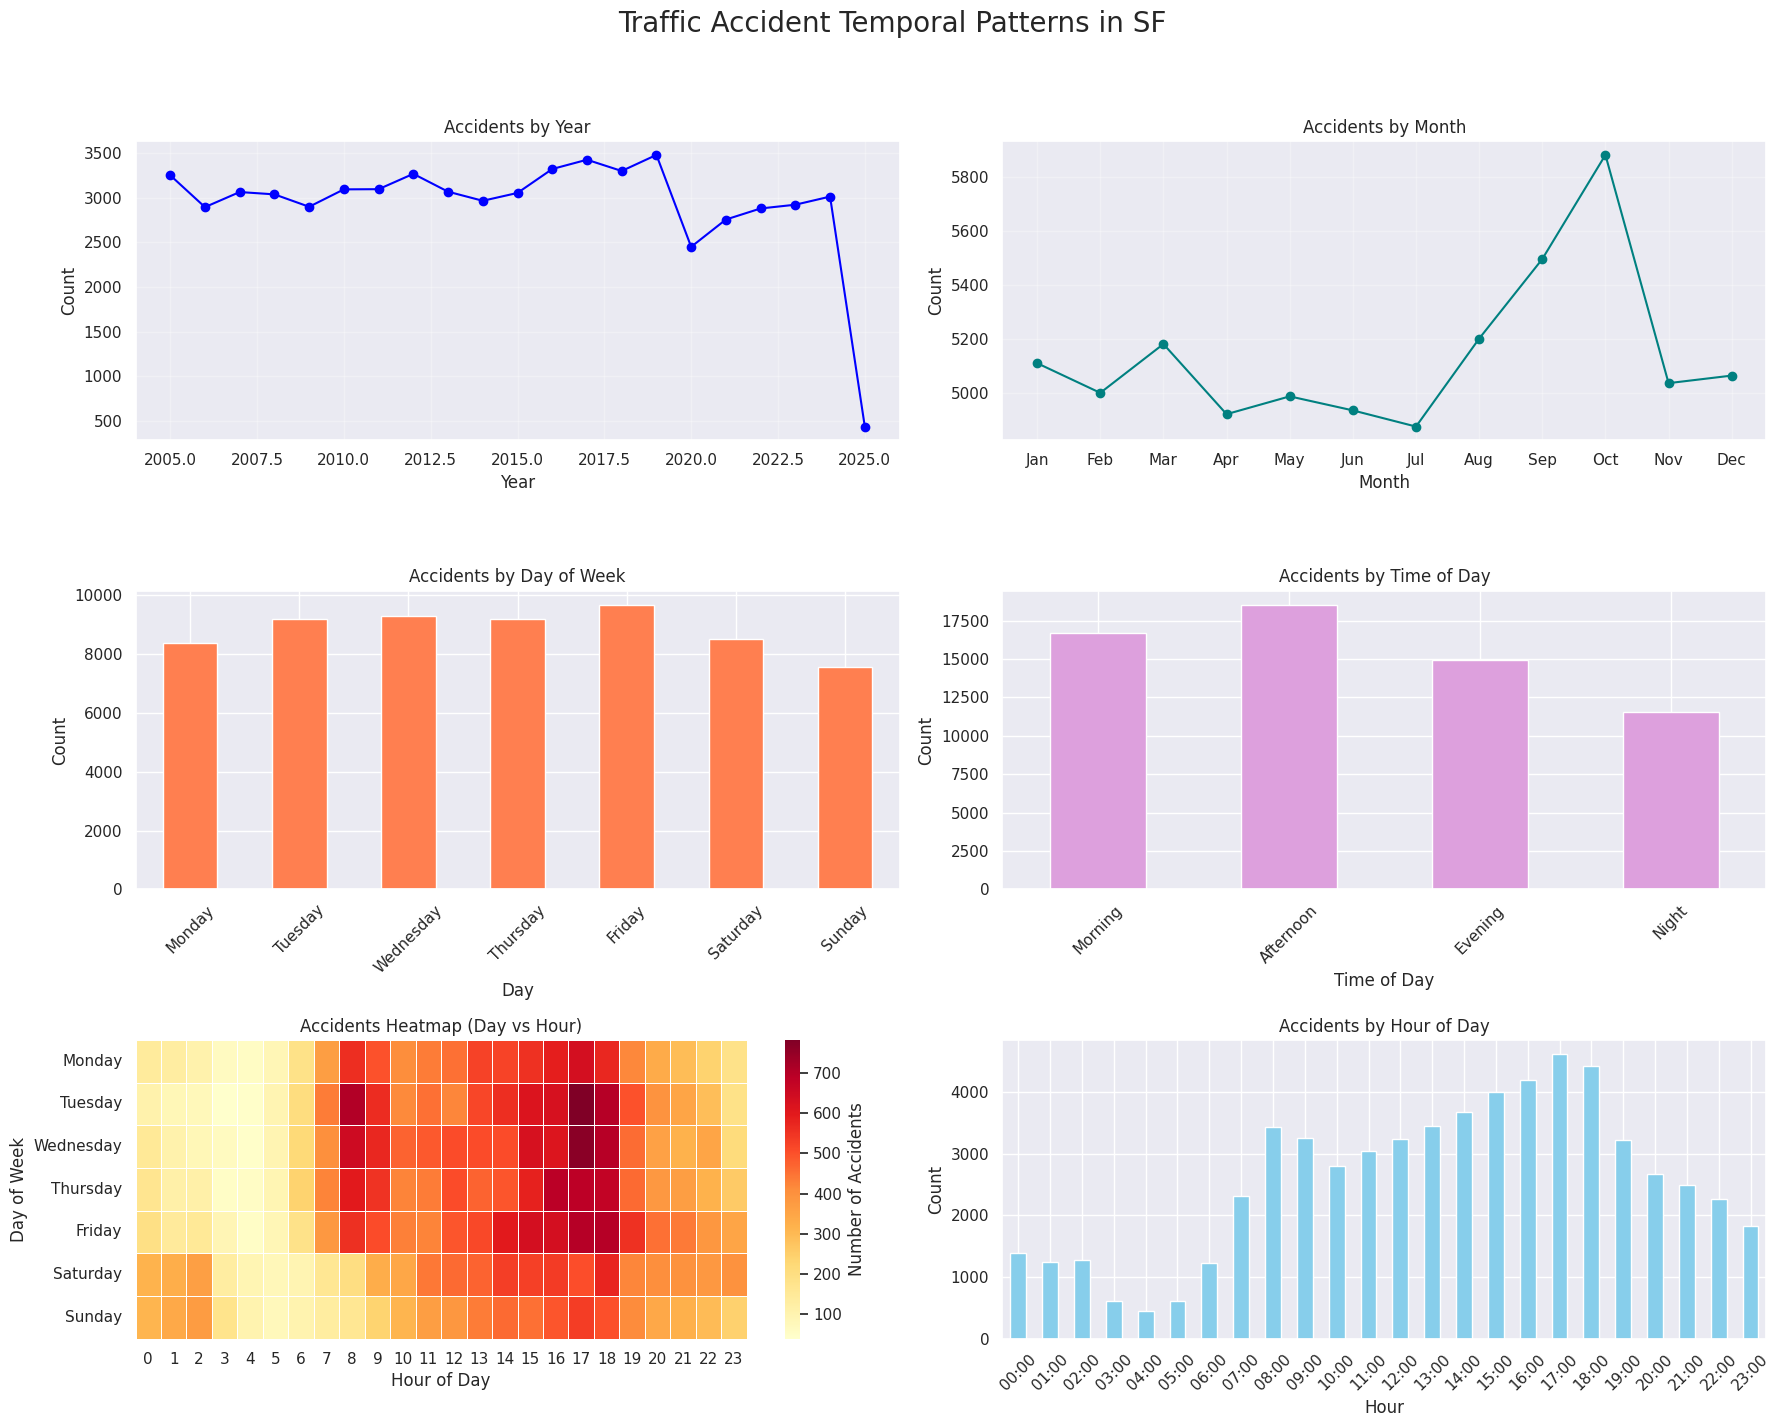

Saved yearly_trend to: results/individual_plots/yearly_trend.png
Saved monthly_trend to: results/individual_plots/monthly_trend.png
Saved weekday_distribution to: results/individual_plots/weekday_distribution.png
Saved time_of_day to: results/individual_plots/time_of_day.png
Saved hourly_distribution to: results/individual_plots/hourly_distribution.png
Saved heatmap_day_hour to: results/individual_plots/heatmap_day_hour.png
All individual plots saved to: results/individual_plots
Temporal Analysis Results:
peak_year: {'year': np.int32(2019), 'count': 3481}
peak_month: {'month': 'October', 'count': 5883}
peak_day: {'day': 'Friday', 'count': 9661}
peak_time: {'time': 'Afternoon', 'count': 18533}
peak_hour: {'hour': np.int32(17), 'count': 4614}
Analysis results saved to: results/temporal_analysis_results.json
Analysis tables saved to: results/analysis_tables


In [ ]:
import os
import json

class TemporalAnalysisVisualizer:
    """Class for creating temporal analysis visualizations of SF traffic accidents"""

    def __init__(self, data, output_dir='results'):
        self.data = data.copy()
        self.output_dir = output_dir
        self.weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        self.time_of_day_order = ['Morning', 'Afternoon', 'Evening', 'Night']

        # Create output directory if it doesn't exist
        os.makedirs(self.output_dir, exist_ok=True)

        # Color scheme
        self.color_palette = {
            'line_chart': 'teal',
            'year_chart': 'blue',
            'month_chart': 'teal',
            'weekday_chart': 'coral',
            'time_of_day_chart': 'plum',
            'heatmap': 'YlOrRd'
        }

    def prepare_data(self):
        """Prepare data for visualization by ensuring all necessary columns exist"""
        if 'collision_datetime' not in self.data.columns:
            raise ValueError("Data must contain 'collision_datetime' column")

        # Ensure datetime format
        self.data['collision_datetime'] = pd.to_datetime(self.data['collision_datetime'], errors='coerce')

        # Extract time features if not present
        if 'hour' not in self.data.columns:
            self.data['hour'] = self.data['collision_datetime'].dt.hour
        if 'year' not in self.data.columns:
            self.data['year'] = self.data['collision_datetime'].dt.year
        if 'month' not in self.data.columns:
            self.data['month'] = self.data['collision_datetime'].dt.month

        # Handle day_of_week - check if it's already in the data and in correct format
        if 'day_of_week' in self.data.columns:
            # Check if it's already in string format (Monday, Tuesday, etc.)
            sample_value = self.data['day_of_week'].iloc[0]
            if isinstance(sample_value, str) and sample_value in self.weekday_order:
                pass  # Already in correct format
            else:
                # Convert to day name format
                self.data['day_of_week'] = self.data['collision_datetime'].dt.day_name()
        else:
            # Create from collision_datetime
            self.data['day_of_week'] = self.data['collision_datetime'].dt.day_name()

        if 'time_of_day' not in self.data.columns:
            self.data['time_of_day'] = self.data['hour'].apply(self._get_time_of_day)

    def _get_time_of_day(self, hour):
        """Helper function to categorize time of day"""
        if 5 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 21:
            return 'Evening'
        else:
            return 'Night'

    def plot_yearly_trend(self, ax=None):
        """Plot accidents by year"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))

        yearly_counts = self.data['year'].value_counts().sort_index()
        yearly_counts.plot(kind='line', marker='o', ax=ax, color=self.color_palette['year_chart'])
        ax.set_title('Accidents by Year')
        ax.set_xlabel('Year')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)

        return ax

    def plot_monthly_trend(self, ax=None):
        """Plot accidents by month"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))

        monthly_counts = self.data['month'].value_counts().sort_index()
        monthly_counts.plot(kind='line', marker='o', color=self.color_palette['month_chart'], ax=ax)
        ax.set_title('Accidents by Month')
        ax.set_xlabel('Month')
        ax.set_ylabel('Count')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        ax.grid(True, alpha=0.3)

        return ax

    def plot_weekday_distribution(self, ax=None):
        """Plot accidents by day of week"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))

        weekday_counts = self.data['day_of_week'].value_counts()

        # Create ordered counts with all weekdays (including those with 0 accidents)
        ordered_counts = pd.Series([weekday_counts.get(day, 0) for day in self.weekday_order],
                                  index=self.weekday_order)

        ordered_counts.plot(kind='bar', color=self.color_palette['weekday_chart'], ax=ax)
        ax.set_title('Accidents by Day of Week')
        ax.set_xlabel('Day')
        ax.set_ylabel('Count')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

        return ax

    def plot_time_of_day(self, ax=None):
        """Plot accidents by time of day"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))

        time_counts = self.data['time_of_day'].value_counts()

        # Create ordered counts with all time periods (including those with 0 accidents)
        ordered_counts = pd.Series([time_counts.get(time, 0) for time in self.time_of_day_order],
                                  index=self.time_of_day_order)

        ordered_counts.plot(kind='bar', color=self.color_palette['time_of_day_chart'], ax=ax)
        ax.set_title('Accidents by Time of Day')
        ax.set_xlabel('Time of Day')
        ax.set_ylabel('Count')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

        return ax

    def plot_hourly_distribution(self, ax=None):
        """Plot accidents by hour"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6))

        hourly_counts = self.data['hour'].value_counts().sort_index()
        hourly_counts.plot(kind='bar', color='skyblue', ax=ax)
        ax.set_title('Accidents by Hour of Day')
        ax.set_xlabel('Hour')
        ax.set_ylabel('Count')
        ax.set_xticks(range(24))
        ax.set_xticklabels([f"{hour:02d}:00" for hour in range(24)], rotation=45)

        return ax

    def plot_heatmap_day_hour(self, ax=None):
        """Plot heatmap of accidents by day and hour"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))

        pivot_table = pd.pivot_table(self.data, values='unique_id',
                                   index='day_of_week',
                                   columns='hour',
                                   aggfunc='count')

        # Ensure all weekdays are present in the pivot table
        complete_index = pd.DataFrame(index=self.weekday_order)
        pivot_table = complete_index.join(pivot_table, how='left').fillna(0)

        sns.heatmap(pivot_table, cmap=self.color_palette['heatmap'],
                   linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of Accidents'})
        ax.set_title('Accidents Heatmap (Day vs Hour)')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Day of Week')

        return ax

    def create_summary_visualization(self, save_path=None):
        """Create comprehensive temporal analysis visualization"""
        self.prepare_data()

        # Create figure with subplots
        fig, axes = plt.subplots(3, 2, figsize=(18, 15))
        fig.suptitle('Traffic Accident Temporal Patterns in SF', fontsize=20, y=0.98)

        # Plot individual charts
        self.plot_yearly_trend(axes[0, 0])
        self.plot_monthly_trend(axes[0, 1])
        self.plot_weekday_distribution(axes[1, 0])
        self.plot_time_of_day(axes[1, 1])
        self.plot_heatmap_day_hour(axes[2, 0])
        self.plot_hourly_distribution(axes[2, 1])  # New hourly distribution

        # Adjust layout
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        # Save if path provided, else use default path
        if save_path is None:
            save_path = os.path.join(self.output_dir, 'temporal_analysis_summary.png')

        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Summary visualization saved to: {save_path}")

        plt.show()

        return fig

    def create_individual_plots(self, save_folder=None):
        """Create and save individual plots"""
        self.prepare_data()

        # Use default folder if none provided
        if save_folder is None:
            save_folder = os.path.join(self.output_dir, 'individual_plots')

        # Create directory if it doesn't exist
        os.makedirs(save_folder, exist_ok=True)

        # Generate and save individual plots
        plots = {
            'yearly_trend': self.plot_yearly_trend,
            'monthly_trend': self.plot_monthly_trend,
            'weekday_distribution': self.plot_weekday_distribution,
            'time_of_day': self.plot_time_of_day,
            'hourly_distribution': self.plot_hourly_distribution,
            'heatmap_day_hour': self.plot_heatmap_day_hour
        }

        for name, plot_func in plots.items():
            fig, ax = plt.subplots(figsize=(10, 8))
            plot_func(ax)
            plt.tight_layout()
            save_path = os.path.join(save_folder, f"{name}.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Saved {name} to: {save_path}")

        print(f"All individual plots saved to: {save_folder}")

    def analyze_temporal_patterns(self):
        """Analyze and return temporal patterns statistics"""
        self.prepare_data()

        analysis = {}

        # Year with most accidents
        year_max = self.data['year'].value_counts().idxmax()
        year_max_count = self.data['year'].value_counts().max()
        analysis['peak_year'] = {'year': year_max, 'count': year_max_count}

        # Month with most accidents
        month_max = self.data['month'].value_counts().idxmax()
        month_names = ['January', 'February', 'March', 'April', 'May', 'June',
                      'July', 'August', 'September', 'October', 'November', 'December']
        month_max_name = month_names[month_max - 1]
        month_max_count = self.data['month'].value_counts().max()
        analysis['peak_month'] = {'month': month_max_name, 'count': month_max_count}

        # Day with most accidents
        day_max = self.data['day_of_week'].value_counts().idxmax()
        day_max_count = self.data['day_of_week'].value_counts().max()
        analysis['peak_day'] = {'day': day_max, 'count': day_max_count}

        # Time of day with most accidents
        time_max = self.data['time_of_day'].value_counts().idxmax()
        time_max_count = self.data['time_of_day'].value_counts().max()
        analysis['peak_time'] = {'time': time_max, 'count': time_max_count}

        # Hour with most accidents
        hour_max = self.data['hour'].value_counts().idxmax()
        hour_max_count = self.data['hour'].value_counts().max()
        analysis['peak_hour'] = {'hour': hour_max, 'count': hour_max_count}

        return analysis

    def save_temporal_analysis(self):
        """Save temporal analysis results to files"""
        analysis = self.analyze_temporal_patterns()

        # Convert NumPy types to Python native types for JSON serialization
        def convert_to_native(obj):
            if isinstance(obj, dict):
                return {key: convert_to_native(value) for key, value in obj.items()}
            elif isinstance(obj, (np.int32, np.int64)):
                return int(obj)
            elif isinstance(obj, (np.float32, np.float64)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            else:
                return obj

        analysis_native = convert_to_native(analysis)

        # Save as JSON
        json_path = os.path.join(self.output_dir, 'temporal_analysis_results.json')
        with open(json_path, 'w') as f:
            json.dump(analysis_native, f, indent=4)
        print(f"Analysis results saved to: {json_path}")

        # Save as CSV for each analysis category
        csv_folder = os.path.join(self.output_dir, 'analysis_tables')
        os.makedirs(csv_folder, exist_ok=True)

        # Save yearly counts
        yearly_counts = self.data['year'].value_counts().sort_index()
        yearly_counts.to_csv(os.path.join(csv_folder, 'yearly_counts.csv'))

        # Save monthly counts
        monthly_counts = self.data['month'].value_counts().sort_index()
        monthly_counts.to_csv(os.path.join(csv_folder, 'monthly_counts.csv'))

        # Save weekday counts
        weekday_counts = self.data['day_of_week'].value_counts()
        # Create ordered counts with all weekdays (including those with 0 accidents)
        ordered_weekday_counts = pd.Series([weekday_counts.get(day, 0) for day in self.weekday_order],
                                         index=self.weekday_order)
        ordered_weekday_counts.to_csv(os.path.join(csv_folder, 'weekday_counts.csv'))

        # Save hourly counts
        hourly_counts = self.data['hour'].value_counts().sort_index()
        hourly_counts.to_csv(os.path.join(csv_folder, 'hourly_counts.csv'))

        # Save time of day counts
        time_counts = self.data['time_of_day'].value_counts()
        # Create ordered counts with all time periods (including those with 0 accidents)
        ordered_time_counts = pd.Series([time_counts.get(time, 0) for time in self.time_of_day_order],
                                      index=self.time_of_day_order)
        ordered_time_counts.to_csv(os.path.join(csv_folder, 'time_of_day_counts.csv'))

        print(f"Analysis tables saved to: {csv_folder}")

# Usage example
# Create visualizer instance
visualizer = TemporalAnalysisVisualizer(df)

# Create and save summary visualization
visualizer.create_summary_visualization()

# Create individual plots
visualizer.create_individual_plots()

# Get temporal analysis statistics
temporal_stats = visualizer.analyze_temporal_patterns()
print("Temporal Analysis Results:")
for key, value in temporal_stats.items():
    print(f"{key}: {value}")

# Save all analysis results
visualizer.save_temporal_analysis()

### Temporal EDA Summary: CrashSight-SF

### 1. Yearly Trends
- **2005–2019**: Traffic accident counts remained relatively stable, averaging around 3,000 per year.
- **2020**: Sharp decline in accidents likely due to COVID-19 lockdown effects.
- **2025**: Extremely low number of records (<500), likely due to incomplete data or future-dated entries — should be handled cautiously.

### 2. Monthly Patterns
- **October** shows the highest number of accidents (~5,900), suggesting seasonal risks may be higher in fall.
- **February to July** displays a relatively flatter and lower trend, possibly related to weather or fewer holidays/events.

### 3. Day of Week
- **Fridays** have the highest number of accidents, exceeding 9,600 — possibly linked to end-of-week commuting rush.
- **Weekends (especially Sundays)** have the fewest accidents, likely due to lower traffic volumes.

### 4. Time of Day
- **Afternoons** experience the most accidents, potentially due to post-work travel congestion.
- **Nighttime** has the fewest accidents but still non-negligible — potentially linked to poor visibility and fatigue.

### 5. Heatmap: Day vs Hour
- Peak accident hours are concentrated between **8:00 AM to 6:00 PM** on weekdays.
- Clear hotspots appear during **commute hours (8–9 AM and 4–6 PM)**,confirming the rush hour risk.


## Spatial Analysis

In [ ]:
# missing geo coordinates
missing_counts = df[["tb_latitude", "tb_longitude"]].isna().sum()
print(missing_counts)

# Drop rows with missing coordinates
df_geo = df.dropna(subset=["tb_latitude", "tb_longitude"])

tb_latitude     173
tb_longitude    173
dtype: int64


In [ ]:
from folium.plugins import HeatMap, MarkerCluster
from scipy.stats import gaussian_kde

class SpatialAnalysisVisualizer:
    """Class for creating spatial analysis visualizations of SF traffic accidents"""

    def __init__(self, data, output_dir='results'):
        self.data = data.copy()
        self.output_dir = output_dir
        self.sf_center = [37.7749, -122.4194]  # San Francisco center coordinates

        # Create output directory if it doesn't exist
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(os.path.join(self.output_dir, 'maps'), exist_ok=True)

        # Filter out records with invalid coordinates
        self.data_geo = self.filter_valid_coordinates()

    def filter_valid_coordinates(self):
        """Filter out records with invalid or missing coordinates"""
        # Define San Francisco bounds
        sf_lat_bounds = (37.7, 37.85)
        sf_lon_bounds = (-122.52, -122.36)

        # Filter data with valid coordinates
        valid_data = self.data[
            (self.data['tb_latitude'].notna()) &
            (self.data['tb_longitude'].notna()) &
            (self.data['tb_latitude'] >= sf_lat_bounds[0]) &
            (self.data['tb_latitude'] <= sf_lat_bounds[1]) &
            (self.data['tb_longitude'] >= sf_lon_bounds[0]) &
            (self.data['tb_longitude'] <= sf_lon_bounds[1])
        ]

        print(f"Filtered data: {len(valid_data)} records with valid coordinates (out of {len(self.data)})")
        return valid_data

    def create_scatter_map(self, save=True):
        """Create a scatter map of accident locations"""
        # Create base map
        base_map = folium.Map(location=self.sf_center, zoom_start=12)

        # Add scatter points
        for _, row in self.data_geo.iterrows():
            folium.CircleMarker(
                location=[row["tb_latitude"], row["tb_longitude"]],
                radius=1,
                color="blue",
                fill=True,
                fill_opacity=0.5
            ).add_to(base_map)

        # Save map
        if save:
            save_path = os.path.join(self.output_dir, 'maps', 'sf_crash_scatter_map.html')
            base_map.save(save_path)
            print(f"Scatter map saved to: {save_path}")

        return base_map

    def create_heatmap(self, save=True):
        """Create a heat map of accident density"""
        # Create base map
        heat_map = folium.Map(location=self.sf_center, zoom_start=12)

        # Prepare data for heatmap
        heat_data = [[row['tb_latitude'], row['tb_longitude']] for _, row in self.data_geo.iterrows()]

        # Add heatmap layer
        HeatMap(heat_data, radius=15, blur=10, max_zoom=13).add_to(heat_map)

        # Save map
        if save:
            save_path = os.path.join(self.output_dir, 'maps', 'sf_crash_heatmap.html')
            heat_map.save(save_path)
            print(f"Heat map saved to: {save_path}")

        return heat_map

    def create_cluster_map(self, save=True):
        """Create a cluster map of accidents"""
        # Create base map
        cluster_map = folium.Map(location=self.sf_center, zoom_start=12)

        # Create marker cluster
        marker_cluster = MarkerCluster()

        # Add markers to cluster
        for _, row in self.data_geo.iterrows():
            folium.Marker(
                location=[row["tb_latitude"], row["tb_longitude"]],
                popup=f"Accident ID: {row.get('case_id_pkey', 'N/A')}"
            ).add_to(marker_cluster)

        # Add cluster to map
        marker_cluster.add_to(cluster_map)

        # Save map
        if save:
            save_path = os.path.join(self.output_dir, 'maps', 'sf_crash_cluster_map.html')
            cluster_map.save(save_path)
            print(f"Cluster map saved to: {save_path}")

        return cluster_map

    def create_severity_map(self, save=True):
        """Create a map colored by accident severity"""
        # Create base map
        severity_map = folium.Map(location=self.sf_center, zoom_start=12)

        # Define color scheme for severity
        severity_colors = {
            1: 'green',    # Minor
            2: 'yellow',   # Moderate
            3: 'orange',   # Serious
            4: 'red'       # Fatal
        }

        # Add colored markers based on severity
        for _, row in self.data_geo.iterrows():
            severity = row.get('collision_severity', 'Unknown')
            color = severity_colors.get(severity, 'gray')

            folium.CircleMarker(
                location=[row["tb_latitude"], row["tb_longitude"]],
                radius=4,
                color=color,
                fill=True,
                fill_opacity=0.7,
                popup=f"Severity: {severity}"
            ).add_to(severity_map)

        # Save map
        if save:
            save_path = os.path.join(self.output_dir, 'maps', 'sf_crash_severity_map.html')
            severity_map.save(save_path)
            print(f"Severity map saved to: {save_path}")

        return severity_map

    def create_kde_plot(self, save=True):
        """Create a KDE density plot of accidents"""
        fig, ax = plt.subplots(figsize=(12, 10))

        # Extract coordinates
        x = self.data_geo['tb_longitude'].values
        y = self.data_geo['tb_latitude'].values

        # Create grid for KDE
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
        xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        values = np.vstack([x, y])

        # Calculate KDE
        kernel = gaussian_kde(values)
        f = np.reshape(kernel(positions).T, xx.shape)

        # Plot KDE
        cfset = ax.contourf(xx, yy, f, cmap='Reds', levels=20, alpha=0.7)
        ax.scatter(x, y, s=1, color='black', alpha=0.1)

        # Customize plot
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title('Accident Density in San Francisco (KDE)')
        plt.colorbar(cfset, label='Density')

        # Save plot
        if save:
            save_path = os.path.join(self.output_dir, 'accident_density_kde.png')
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"KDE plot saved to: {save_path}")
        else:
            plt.show()

        return fig

    def create_neighborhood_analysis(self, save=True):
        """Create analysis visualization by neighborhood"""
        if 'analysis_neighborhood' not in self.data_geo.columns:
            print("No neighborhood data available")
            return None

        # Count accidents by neighborhood
        neighborhood_counts = self.data_geo['analysis_neighborhood'].value_counts()

        # Create horizontal bar plot
        fig, ax = plt.subplots(figsize=(12, 10))
        neighborhood_counts.plot(kind='barh', ax=ax, color='skyblue')

        ax.set_xlabel('Number of Accidents')
        ax.set_ylabel('Neighborhood')
        ax.set_title('Accidents by Neighborhood in San Francisco')
        plt.tight_layout()

        # Save plot
        if save:
            save_path = os.path.join(self.output_dir, 'accident_by_neighborhood.png')
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Neighborhood analysis saved to: {save_path}")
        else:
            plt.show()

        return fig

    def create_all_visualizations(self):
        """Create all spatial visualizations"""
        print("Creating all spatial visualizations...")

        # Create different map types
        self.create_scatter_map()
        self.create_heatmap()
        self.create_cluster_map()

        # Create severity map if severity data is available
        if 'collision_severity' in self.data_geo.columns:
            self.create_severity_map()

        # Create density and neighborhood analysis
        self.create_kde_plot()
        self.create_neighborhood_analysis()

        print("All spatial visualizations created successfully!")

    def get_hotspot_locations(self, threshold_percentile=95):
        """Identify hotspot locations based on density"""
        # Calculate density using KDE
        x = self.data_geo['tb_longitude'].values
        y = self.data_geo['tb_latitude'].values
        values = np.vstack([x, y])
        kernel = gaussian_kde(values)

        # Evaluate density at each point
        densities = kernel.evaluate(values)

        # Find hotspots based on threshold
        threshold = np.percentile(densities, threshold_percentile)
        hotspot_indices = densities > threshold

        # Get hotspot locations
        hotspots = self.data_geo.iloc[hotspot_indices].copy()
        hotspots['density'] = densities[hotspot_indices]

        # Sort by density
        hotspots = hotspots.sort_values('density', ascending=False)

        return hotspots

In [ ]:
# Usage example
# Create visualizer instance
spatial_visualizer = SpatialAnalysisVisualizer(df)

# Create all visualizations
spatial_visualizer.create_all_visualizations()

# Get hotspot locations
hotspots = spatial_visualizer.get_hotspot_locations()
print(f"Found {len(hotspots)} hotspot locations")

Filtered data: 61523 records with valid coordinates (out of 61700)
Creating all spatial visualizations...
Scatter map saved to: results/maps/sf_crash_scatter_map.html
Heat map saved to: results/maps/sf_crash_heatmap.html
Cluster map saved to: results/maps/sf_crash_cluster_map.html
Severity map saved to: results/maps/sf_crash_severity_map.html
KDE plot saved to: results/accident_density_kde.png
Neighborhood analysis saved to: results/accident_by_neighborhood.png
All spatial visualizations created successfully!
Found 3077 hotspot locations


In [ ]:
scatter_map = spatial_visualizer.create_scatter_map(save=False)
scatter_map

In [ ]:
heatmap = spatial_visualizer.create_heatmap(save=False)
heatmap

In [ ]:
cluster_map = spatial_visualizer.create_cluster_map(save=False)
cluster_map

In [ ]:
severity_map = spatial_visualizer.create_severity_map(save=False)
severity_map

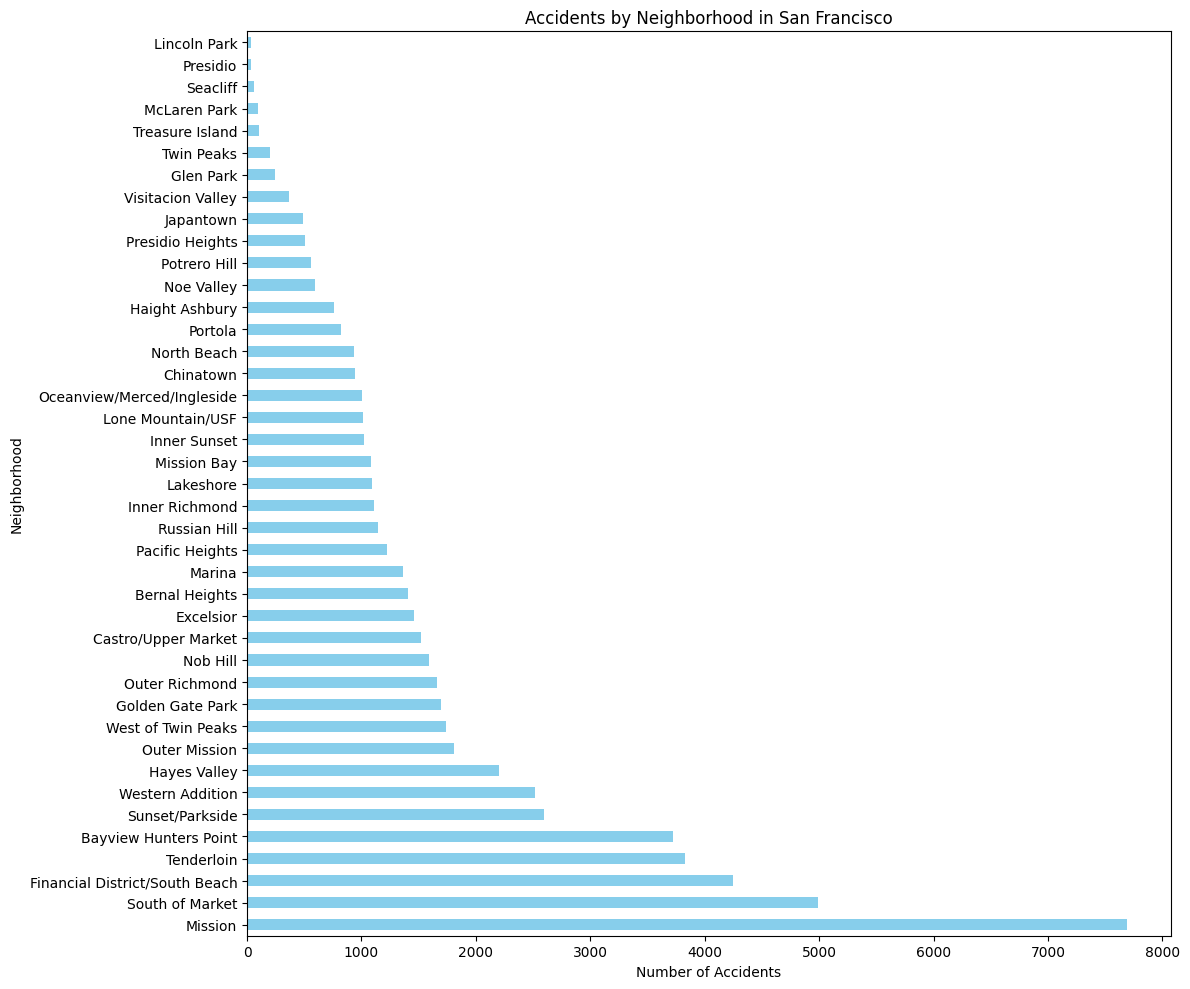

In [ ]:
neighborhood_analysis = spatial_visualizer.create_neighborhood_analysis(save=False)

## Collision Characteristics Analysis

In [ ]:
df["type_of_collision"].value_counts().head(10)

,count
type_of_collision,
Broadside,18893
Vehicle/Pedestrian,12908
Rear End,10001
Sideswipe,8074
Head-On,3712
Other,3218
Hit Object,2342
Not Stated,1439
Overturned,1113


In [ ]:
df["collision_severity"].value_counts()

,count
collision_severity,
Injury (Complaint of Pain),39248
Injury (Other Visible),17529
Injury (Severe),4337
Fatal,585
Medical,1


In [ ]:
df["weather_1"].value_counts().head(10)

,count
weather_1,
Clear,50828
Cloudy,5986
Raining,3658
Not Stated,670
Fog,262
Other,238
Wind,49
Snowing,2
Fog / Visibility,1


In [ ]:
df["road_surface"].value_counts()

,count
road_surface,
Dry,54199
Wet,6295
Not Stated,1086
Slippery,86
Snowy or Icy,34


In [ ]:
df["lighting"].value_counts()

,count
lighting,
Daylight,39727
Dark - Street Lights,18641
Dusk - Dawn,2162
Not Stated,608
Dark - No Street Lights,453
Dark - Street Lights Not Functioning,109


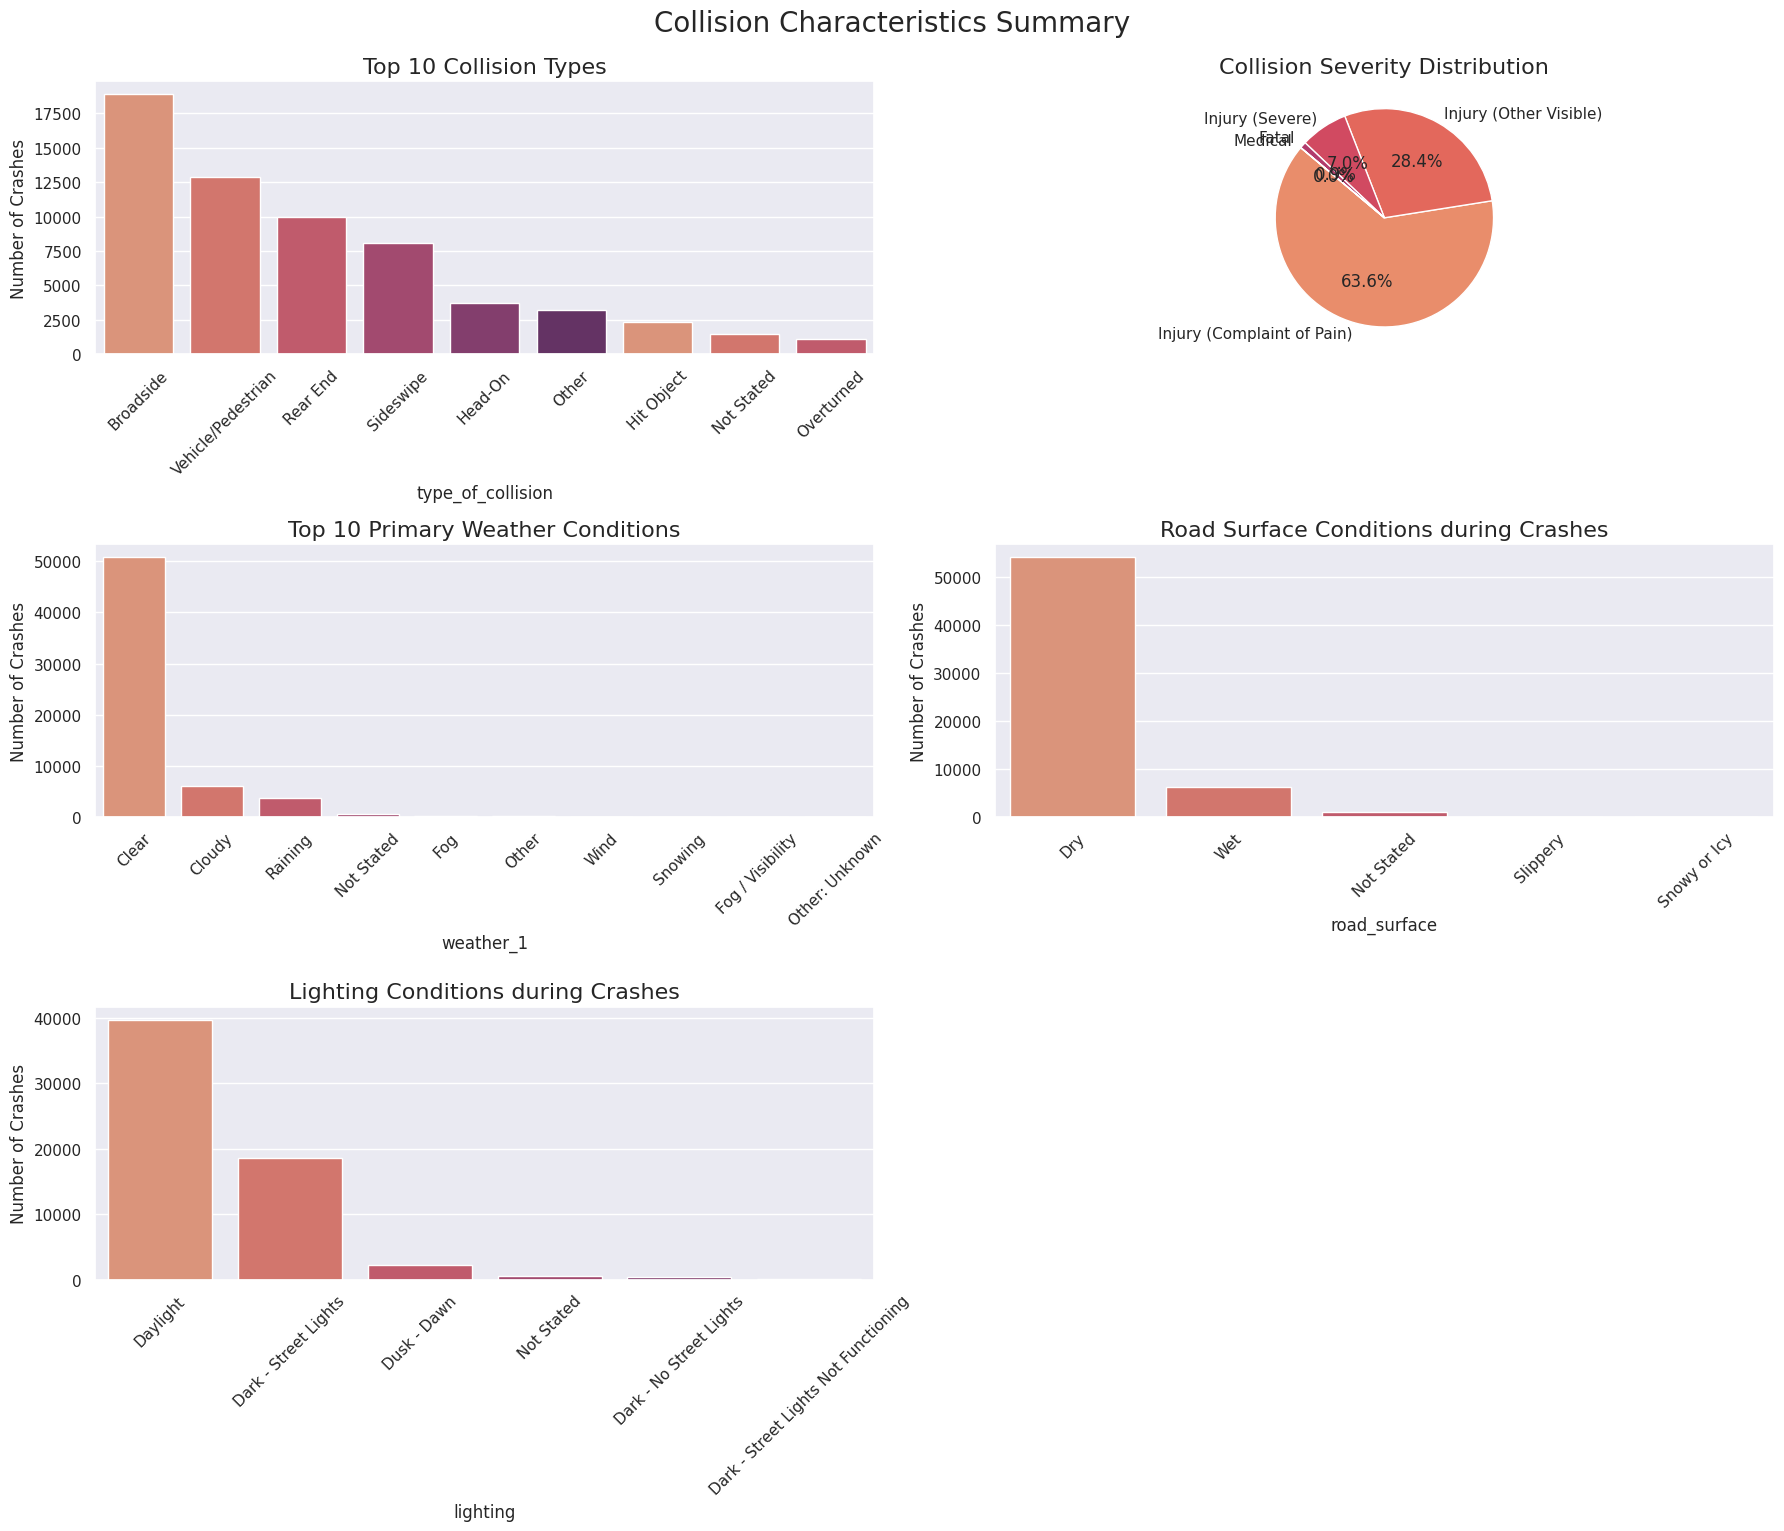

In [ ]:
sns.set(style="darkgrid")
palette = sns.color_palette("flare")

# Create a big figure with multiple subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 15))  # 3 rows × 2 columns
axes = axes.flatten()  # Flatten for easier indexing

# 1. Top 10 Collision Types
type_counts = df["type_of_collision"].value_counts().head(10)
sns.barplot(x=type_counts.index, y=type_counts.values, palette=palette, ax=axes[0])
axes[0].set_title("Top 10 Collision Types", fontsize=16)
axes[0].set_ylabel("Number of Crashes")
axes[0].tick_params(axis='x', rotation=45)

# 2. Collision Severity (Pie Chart)
severity_counts = df["collision_severity"].value_counts()
axes[1].pie(severity_counts.values, labels=severity_counts.index, autopct="%1.1f%%", colors=palette, startangle=140)
axes[1].set_title("Collision Severity Distribution", fontsize=16)

# 3. Top 10 Primary Weather Conditions
weather1_counts = df["weather_1"].value_counts().head(10)
sns.barplot(x=weather1_counts.index, y=weather1_counts.values, palette=palette, ax=axes[2])
axes[2].set_title("Top 10 Primary Weather Conditions", fontsize=16)
axes[2].set_ylabel("Number of Crashes")
axes[2].tick_params(axis='x', rotation=45)

# 4. Road Surface Conditions
road_surface_counts = df["road_surface"].value_counts()
sns.barplot(x=road_surface_counts.index, y=road_surface_counts.values, palette=palette, ax=axes[3])
axes[3].set_title("Road Surface Conditions during Crashes", fontsize=16)
axes[3].set_ylabel("Number of Crashes")
axes[3].tick_params(axis='x', rotation=45)

# 5. Lighting Conditions
lighting_counts = df["lighting"].value_counts()
sns.barplot(x=lighting_counts.index, y=lighting_counts.values, palette=palette, ax=axes[4])
axes[4].set_title("Lighting Conditions during Crashes", fontsize=16)
axes[4].set_ylabel("Number of Crashes")
axes[4].tick_params(axis='x', rotation=45)

# 6. Leave the last (empty) subplot clean
fig.delaxes(axes[5])

# Layout adjustment
plt.tight_layout()
plt.suptitle("Collision Characteristics Summary", fontsize=20, y=1.02)  # Title for the whole figure

# Save the whole figure
fig.savefig("results/collision_characteristics_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### Collision Characteristics Summary



This section analyzes the physical and environmental features of traffic collisions in San Francisco.

### 🔹 Top 10 Collision Types
The most common collision type is **Broadside**, followed by **Vehicle/Pedestrian** and **Rear End**. These types likely occur at intersections or due to visibility and speed management issues.

### 🔹 Collision Severity
Most crashes result in **non-fatal injuries**:
- 63.6% of incidents involve **complaints of pain**
- 28.4% result in **visible injuries**
- Less than 1% are **fatal**

This highlights the importance of **preventive measures** even for seemingly "minor" incidents.

### 🔹 Primary Weather Conditions
Crashes predominantly occur under **clear weather conditions**, suggesting that **weather is not a major trigger** in most incidents. However, **rain and fog** still account for a non-negligible share and could be linked to reduced visibility.

### 🔹 Road Surface Conditions
An overwhelming majority of crashes happen on **dry roads**, reinforcing the observation that most accidents are not weather-induced but possibly **behavioral or infrastructure-related**.

### 🔹 Lighting Conditions
Most crashes happen during **daylight**, followed by **dark conditions with street lighting**. Very few occur when **street lights are absent or not functioning**, suggesting lighting infrastructure is mostly in place but **driver alertness** remains key.

---

📎 *All five charts are presented in the combined figure for better comparative insights. Saved as `results/collision_characteristics_summary.png`*

In [ ]:
import folium
from folium.plugins import HeatMap, MarkerCluster

# Create a base map centered on San Francisco
sf_center = [37.7749, -122.4194]
m = folium.Map(location=sf_center, zoom_start=12)

# Add a heatmap layer showing all crashes
all_crashes = df_geo[["tb_latitude", "tb_longitude"]].dropna().values.tolist()
HeatMap(all_crashes, name="All Crashes Heatmap", radius=10, blur=15).add_to(m)

# Add a cluster layer for fatal crashes
fatal_df = df_geo[df_geo["collision_severity"].str.contains("Fatal", na=False)]
fatal_cluster = MarkerCluster(name="Fatal Crashes").add_to(m)

for _, row in fatal_df.iterrows():
    folium.CircleMarker(
        location=[row["tb_latitude"], row["tb_longitude"]],
        radius=5,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['collision_datetime']}<br>Type: {row['type_of_collision']}"
    ).add_to(fatal_cluster)

# Add separate layers for daytime and nighttime crashes
night_df = df_geo[df_geo["lighting"].str.contains("Dark", na=False)]
day_df = df_geo[df_geo["lighting"].str.contains("Daylight", na=False)]

for label, df_sub, color in [("Night Crashes", night_df, "blue"), ("Daytime Crashes", day_df, "orange")]:
    group = folium.FeatureGroup(name=label)
    for _, row in df_sub.iterrows():
        folium.CircleMarker(
            location=[row["tb_latitude"], row["tb_longitude"]],
            radius=3,
            color=color,
            fill=True,
            fill_opacity=0.4
        ).add_to(group)
    group.add_to(m)

# Add a layer control panel
folium.LayerControl().add_to(m)

# Save the final combined map to an HTML file
m.save("results/sf_combined_crash_map.html")

# Display the map directly inside Jupyter Notebook (optional)
m

## Responsibility Analysis

This interactive map provides a layered view of San Francisco traffic crashes, including overall crash density, locations of fatal collisions, and patterns of daytime and nighttime accidents, helping users intuitively explore spatial crash patterns across the city.


In [ ]:
df["party_at_fault"].value_counts().sort_index()

TypeError: '<' not supported between instances of 'str' and 'float'

In [ ]:
# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("Set2")

# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Party at fault (left plot)
party_fault_counts = df["party_at_fault"].value_counts().sort_index()
sns.barplot(
    x=party_fault_counts.index,
    y=party_fault_counts.values,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Distribution of Party at Fault", fontsize=16)
axes[0].set_xlabel("Party at Fault\n(0 = Not at Fault, 1 = At Fault)", fontsize=12)
axes[0].set_ylabel("Number of Cases", fontsize=12)
axes[0].set_xticks([0, 1])

# 2. Vehicle types involved (right plot)
vehicle_types = pd.concat([df["party1_type"], df["party2_type"]], ignore_index=True)
vehicle_type_counts = vehicle_types.value_counts().head(10)

sns.barplot(
    x=vehicle_type_counts.index,
    y=vehicle_type_counts.values,
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("Top 10 Vehicle Types Involved", fontsize=16)
axes[1].set_xlabel("Vehicle Type", fontsize=12)
axes[1].set_ylabel("Number of Involvements", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure
plt.savefig("results/responsibility_analysis_summary.png")

# Show plot
plt.show()

🧑‍⚖️ Responsibility Analysis Summary
The analysis of traffic crash responsibility reveals two key insights:

**Party at Fault:** The vast majority of recorded accidents identify a responsible party (1 = At Fault), with very few marked as not at fault or left undefined. This suggests that most crash records successfully identify who was at fault, allowing for reliable responsibility attribution.

**Vehicle Types Involved:** Drivers are by far the most frequently involved party in collisions, followed by pedestrians and bicyclists. The presence of parked vehicles and other types also appears, although at much lower frequencies.

This indicates that improving driver behavior could have a substantial impact on reducing overall crashes in San Francisco.